<a href="https://colab.research.google.com/github/LizethMesaC/TrabajoFinalCDD/blob/main/Trabajo_Final_CDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family: Arial;">
<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">
<h3 style="text-align: center;">
<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>
</h3>
<h3 style="text-align: center; color:  #C2262B;"> <!--Color institucional-->
<strong>Módulo Introducción a la Ciencia de Datos<strong>
</h3>
<h3>
<b>Trabajo Final:</b> <u>Estimación de niveles de obesidad basada en hábitos alimenticios y condición física</u>
</h3>
<hr style="width:100%; border:1px solid withe;">
<h6 style="text-align: rigth; margin-bottom: 5px">
<b> Integrantes:</b>
<ul>
    <li>Yuly Del Carmen Mosquera Martinez</li>
    <li>Yeny Liliana Guzman Urrego</li>
    <li>Angie Carolina Piedrahita Cañaveral</li>
    <li>Lizeth Mesa Cadavid</li>
</ul>
</h3


---

##**Detalles Dataset**
El conjunto de datos seleccionado está diseñado para estimar los niveles de obesidad en personas de México, Perú y Colombia, a partir de sus hábitos alimenticios y condición física.

 Contiene 2111 registros y 17 variables que describen características como estilo de vida, alimentación y actividad física. La variable objetivo, denominada NObesity, clasifica a los individuos en siete categorías:
- Peso insuficiente  
- Peso normal  
- Sobrepeso nivel I  
- Sobrepeso nivel II  
- Obesidad tipo I  
- Obesidad tipo II  
- Obesidad tipo III

Es importante destacar que el 77% de los datos fue generado de forma sintética mediante técnicas como SMOTE, mientras que el 23% proviene de datos reales recolectados a través de una plataforma web.

##**Objetivo General**
Analizar los factores relacionados con los hábitos de vida, alimentación y actividad física que influyen en el nivel de obesidad de los individuos, mediante un Análisis Exploratorio de Datos (EDA), con el fin de identificar patrones relevantes y posibles relaciones entre variables.

##**Objetivos especificos**
1. Determinar qué variables están más relacionadas con el nivel de obesidad (NObeyesdad).
2. Analizar si el consumo de alimentos altos en calorías (FAVC) influye en el nivel de obesidad.
3. Evaluar la relación entre la frecuencia de comidas entre horas (CAEC) y el nivel de obesidad.
4. Examinar la relación entre la actividad física (FAF) y el nivel de obesidad.
5. Identificar si el medio de transporte utilizado (MTRANS) influye en el nivel de obesidad.
6. Determinar si los antecedentes familiares de obesidad influyen en el nivel actual de obesidad.
7. Analizar si existen relación en el nivel de obesidad y el género.
8. Determinar si la edad tiene relación con el nivel de obesidad.



#**Variables del conjunto de datos:**
| N° | NOMBRE DE LA VARIABLE | DESCRIPCIÓN | TIPO DE DATO |
|:--:|:----------------------|:-------------|:-------------:|
| 1 | Gender | Género del individuo | Categórico |
| 2 | Age | Edad de la persona | Continuo |
| 3 | Height | Estatura | Continuo |
| 4 | Weight | Peso | Continuo |
| 5 | family_history_with_overweight | Antecedentes familiares de sobrepeso | Binario |
| 6 | FAVC | Consumo frecuente de alimentos altos en calorías | Binario |
| 7 | FCVC | Frecuencia de consumo de verduras | Entero |
| 8 | NCP | Número de comidas principales al día | Continuo |
| 9 | CAEC | Consumo de alimentos entre comidas | Categórico |
| 10 | SMOKE | Si la persona fuma o no | Binario |
| 11 | CH2O | Consumo de agua diario | Continuo |
| 12 | SCC | Control de calorías consumidas | Binario |
| 13 | FAF | Actividad física semanal | Continuo |
| 14 | TUE | Tiempo usando dispositivos tecnológicos | Entero |
| 15 | CALC | Consumo de alcohol | Categórico |
| 16 | MTRANS | Medio de transporte utilizado | Categórico |
| 17 | NObeyesdad | Nivel de obesidad (variable objetivo) | Categórico |


## **1. Importación de librerías**

In [1]:
"""Importamos librerías"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

!pip install ucimlrepo

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 52
rng = np.random.default_rng(RANDOM_STATE)

## **2. Revisión del conjunto de datos**

### ***2.1 Carga de datos***

In [2]:
# Importar una función de la librería ucimlrepo, que permite acceder a datasets del repositorio UCI.
from ucimlrepo import fetch_ucirepo

# Se descarga el Datasets con el ID=544 que corresponde al de Obesidad
Dataset = fetch_ucirepo(id=544)

# Separamos las variables independientes de la variable objetivo para futuros análisis
x = Dataset.data.features
y = Dataset.data.targets

# Unificar todo el dataset
df_Obesidad = pd.concat([x, y], axis=1)

#Mostrar las primeras filas
df_Obesidad.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000,1.620,64.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,0.000,1.000,no,Public_Transportation,Normal_Weight
1,Female,21.000,1.520,56.000,yes,no,3.000,3.000,Sometimes,yes,3.000,yes,3.000,0.000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000,1.800,77.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,2.000,1.000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000,1.800,87.000,no,no,3.000,3.000,Sometimes,no,2.000,no,2.000,0.000,Frequently,Walking,Overweight_Level_I
4,Male,22.000,1.780,89.800,no,no,2.000,1.000,Sometimes,no,2.000,no,0.000,0.000,Sometimes,Public_Transportation,Overweight_Level_II


### ***2.2. Examinar estructura de datos***

In [3]:
# Numero de filas y columnas
print(f"Número de filas: {df_Obesidad.shape[0]}")
print(f"Número de columnas: {df_Obesidad.shape[1]}")

#Tablas con las columnas, la cantidad de valores no están vacíos y el tipo de datos
print("\n Información del Dataset:")

info_df = pd.DataFrame({
    "Column": df_Obesidad.columns,
    "Non-Null": df_Obesidad.notnull().sum().values,
    "Dtype": df_Obesidad.dtypes.values
})
info_df

Número de filas: 2111
Número de columnas: 17

 Información del Dataset:


,Column,Non-Null,Dtype
0,Gender,2111,object
1,Age,2111,float64
2,Height,2111,float64
3,Weight,2111,float64
4,family_history_with_overweight,2111,object
5,FAVC,2111,object
6,FCVC,2111,float64
7,NCP,2111,float64
8,CAEC,2111,object
9,SMOKE,2111,object


### **Análisis**
Se observa que el DataSet no contiene valores nulos  o faltantes en ninguna de sus columnas

### ***2.3. Limpieza de datos***

Cambiamos los nombres de algunas columnas para entenderlas mejor

| TÍTULO ACTUAL | NUEVO TÍTULO |
|:--:|:----------------------:|
|Family_history_with_overweight | Family_history_overweight |
|FAVC| Frequent_high_caloric_food |
|FCVC| Frequent_consumption_vegetables|
|NCP | Number_of_main_meals |
|CAEC | Food_between_meals |
|CH2O | Daily_Water_Intake |
|SCC | Calorie_Monitoring |
|FAF | Physical_Activity_Frequency |
|TUE | Technology_Use_Time |
|CALC | Alcohol_Consumption |
|MTRANS | Transportation_type |
|NObeyesdad | Obesity_Level |




In [4]:
# Realizamos una copia del DataSet para no modificar el original

Obesidad_DataSet = df_Obesidad.rename(columns={
    "family_history_with_overweight": "Family_history_overweight",
    "FAVC": "Frequent_high_caloric_food",
    "FCVC":	"Frequent_consumption_vegetables",
    "NCP": "Number_of_main_meals",
    "CAEC": "Food_between_meals",
    "SMOKE": "Smoke",
    "CH2O": "Daily_Water_Intake",
    "SCC": "Calorie_Monitoring",
    "FAF": "Physical_Activity_Frequency",
    "TUE": "Technology_Use_Time",
    "CALC": "Alcohol_Consumption",
    "MTRANS": "Transportation_type",
    "NObeyesdad": "Obesity_Level"
})

# Visualizar los cambios
Obesidad_DataSet.head()

,Gender,Age,Height,Weight,Family_history_overweight,Frequent_high_caloric_food,Frequent_consumption_vegetables,Number_of_main_meals,Food_between_meals,Smoke,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Technology_Use_Time,Alcohol_Consumption,Transportation_type,Obesity_Level
0,Female,21.000,1.620,64.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,0.000,1.000,no,Public_Transportation,Normal_Weight
1,Female,21.000,1.520,56.000,yes,no,3.000,3.000,Sometimes,yes,3.000,yes,3.000,0.000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000,1.800,77.000,yes,no,2.000,3.000,Sometimes,no,2.000,no,2.000,1.000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000,1.800,87.000,no,no,3.000,3.000,Sometimes,no,2.000,no,2.000,0.000,Frequently,Walking,Overweight_Level_I
4,Male,22.000,1.780,89.800,no,no,2.000,1.000,Sometimes,no,2.000,no,0.000,0.000,Sometimes,Public_Transportation,Overweight_Level_II


Revisamos la calidad del dato buscando registros duplicados

In [5]:
duplicados = Obesidad_DataSet.duplicated().sum()
porcentaje = (duplicados / len(Obesidad_DataSet)) * 100

print(f"Duplicados: {duplicados}")
print(f"Porcentaje: {porcentaje:.2f}%")

#Visualizar filas duplicadas incluyendo la primera aparición
Obesidad_DataSet [Obesidad_DataSet.duplicated(keep=False)]

Duplicados: 24
Porcentaje: 1.14%


,Gender,Age,Height,Weight,Family_history_overweight,Frequent_high_caloric_food,Frequent_consumption_vegetables,Number_of_main_meals,Food_between_meals,Smoke,Daily_Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Technology_Use_Time,Alcohol_Consumption,Transportation_type,Obesity_Level
97,Female,21.000,1.520,42.000,no,no,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.000,1.520,42.000,no,no,3.000,1.000,Frequently,no,1.000,no,0.000,0.000,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.000,1.570,55.000,no,yes,2.000,1.000,Sometimes,no,2.000,no,2.000,0.000,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.000,1.570,55.000,no,yes,2.000,1.000,Sometimes,no,2.000,no,2.000,0.000,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.000,1.620,70.000,no,yes,2.000,1.000,no,no,3.000,no,1.000,0.000,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.000,1.620,70.000,no,yes,2.000,1.000,no,no,3.000,no,1.000,0.000,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.000,1.620,70.000,no,yes,2.000,1.000,no,no,3.000,no,1.000,0.000,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.000,1.620,70.000,no,yes,2.000,1.000,no,no,3.000,no,1.000,0.000,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.000,1.690,65.000,yes,yes,2.000,3.000,Sometimes,no,2.000,no,1.000,1.000,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.000,1.690,65.000,yes,yes,2.000,3.000,Sometimes,no,2.000,no,1.000,1.000,Sometimes,Public_Transportation,Normal_Weight


### **Decisión**

Pesé a que el porcentaje de regisros duplicados es poco, se identifica un error en los datos al ser un duplicado exacto en toda la fila, por lo tanto se eliminarán para evitar sesgos en los análisis.

In [ ]:
# Se eliminan los registros duplicados y se reinicia el índice
Obesidad_DataSet = Obesidad_DataSet.drop_duplicates().reset_index(drop=True)

#Verificamos si se eliminaron los duplicados
print(Obesidad_DataSet.duplicated().sum())

0


### ***2.4. Transformación de datos***

Exploramos las variables categóricas

In [6]:
# Buscamos las columnas tipo (Object) y las seleccionamos
colum_categ = Obesidad_DataSet.select_dtypes(include="object").columns

for col in colum_categ:
    print(f"\n🔹 Columna: {col}")

    # Valores únicos (fuera de la tabla)
    print("Valores únicos:", Obesidad_DataSet[col].unique(), "\n")

    # Tabla de frecuencias
    display(Obesidad_DataSet[col].value_counts().to_frame("Frecuencia"))




🔹 Columna: Gender
Valores únicos: ['Female' 'Male'] 



,Frecuencia
Gender,
Male,1068
Female,1043



🔹 Columna: Family_history_overweight
Valores únicos: ['yes' 'no'] 



,Frecuencia
Family_history_overweight,
yes,1726
no,385



🔹 Columna: Frequent_high_caloric_food
Valores únicos: ['no' 'yes'] 



...

,Frecuencia
Alcohol_Consumption,
Sometimes,1401
no,639
Frequently,70
Always,1



🔹 Columna: Transportation_type
Valores únicos: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike'] 



,Frecuencia
Transportation_type,
Public_Transportation,1580
Automobile,457
Walking,56
Motorbike,11
Bike,7



🔹 Columna: Obesity_Level
Valores únicos: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III'] 



,Frecuencia
Obesity_Level,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


Recategorizamos las variables categoricas para mejorar la precisión de los análisis

In [7]:
# Variables categoricas binarias

col_binarias = [
    "Family_history_overweight",
    "Frequent_high_caloric_food",
    "Smoke",
    "Calorie_Monitoring"
]

for col in col_binarias:
    Obesidad_DataSet[col] = Obesidad_DataSet[col].map({"no": 0, "yes": 1})

print("\n\n Variables Binarias luego de la conversión")
for col in col_binarias:
    print(f"\n{col}")
    print(Obesidad_DataSet[col].value_counts())



 Variables Binarias luego de la conversión

Family_history_overweight
Family_history_overweight
1    1726
0     385
Name: count, dtype: int64

Frequent_high_caloric_food
Frequent_high_caloric_food
1    1866
0     245
Name: count, dtype: int64

Smoke
Smoke
0    2067
1      44
Name: count, dtype: int64

Calorie_Monitoring
Calorie_Monitoring
0    2015
1      96
Name: count, dtype: int64


In [8]:
#Variables categóricas ordinales

escala_ordinal = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

variables_ordinales = [
    "Food_between_meals",
    "Alcohol_Consumption"
]

for col in variables_ordinales:
    Obesidad_DataSet[col] = Obesidad_DataSet[col].str.strip().map(escala_ordinal)

print(" Variables ordinales luego de la conversión:")

for col in variables_ordinales:
    print(f"\n{col}")
    print(Obesidad_DataSet[col].value_counts())

 Variables ordinales luego de la conversión:

Food_between_meals
Food_between_meals
1    1765
2     242
3      53
0      51
Name: count, dtype: int64

Alcohol_Consumption
Alcohol_Consumption
1    1401
0     639
2      70
3       1
Name: count, dtype: int64


In [9]:
#Visualizamos la información del DataSet

Obesidad_DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Gender                           2111 non-null   object 
 1   Age                              2111 non-null   float64
 2   Height                           2111 non-null   float64
 3   Weight                           2111 non-null   float64
 4   Family_history_overweight        2111 non-null   int64  
 5   Frequent_high_caloric_food       2111 non-null   int64  
 6   Frequent_consumption_vegetables  2111 non-null   float64
 7   Number_of_main_meals             2111 non-null   float64
 8   Food_between_meals               2111 non-null   int64  
 9   Smoke                            2111 non-null   int64  
 10  Daily_Water_Intake               2111 non-null   float64
 11  Calorie_Monitoring               2111 non-null   int64  
 12  Physical_Activity_Fr

## **3. Análisis Descriptivo Univariado**



In [10]:
#Separamos las variables categóricas y numéricas

num_cols = Obesidad_DataSet.select_dtypes(include="number").columns
cat_cols = Obesidad_DataSet.select_dtypes(include="object").columns

### ***3.1 Analisis variables numéricas***



In [11]:
#Media, mediana, min y max, percentiles y desviación estándar
Obesidad_DataSet[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"2,111.000",24.313,6.346,14.000,19.947,22.778,26.000,61.000
Height,"2,111.000",1.702,0.093,1.450,1.630,1.700,1.768,1.980
Weight,"2,111.000",86.586,26.191,39.000,65.473,83.000,107.431,173.000
Family_history_overweight,"2,111.000",0.818,0.386,0.000,1.000,1.000,1.000,1.000
Frequent_high_caloric_food,"2,111.000",0.884,0.320,0.000,1.000,1.000,1.000,1.000
Frequent_consumption_vegetables,"2,111.000",2.419,0.534,1.000,2.000,2.386,3.000,3.000
Number_of_main_meals,"2,111.000",2.686,0.778,1.000,2.659,3.000,3.000,4.000
Food_between_meals,"2,111.000",1.141,0.469,0.000,1.000,1.000,1.000,3.000
Smoke,"2,111.000",0.021,0.143,0.000,0.000,0.000,0.000,1.000
Daily_Water_Intake,"2,111.000",2.008,0.613,1.000,1.585,2.000,2.477,3.000


### **Interpretación**

*   El promedio de edad es de 24 años. Sin embargo, la persona más joven tiene 14 años y la mayor 61 años. Como el 75% de la gente tiene 26 años o menos, se puede inferir que la gran mayoría de los participantes son población de adultos jóvenes.
*   El promedio de historial familiar con sobrepeso es 0.82. Como esto es una variable binaria (0 o 1), significa que el 82% de los participantes tiene familiares con sobrepeso.
* El 88% de las personas consume alimentos altos en calorías frecuentemente.

In [12]:
#Asimetria
Obesidad_DataSet[num_cols].skew()

,0
Age,1.529
Height,-0.013
Weight,0.255
Family_history_overweight,-1.646
Frequent_high_caloric_food,-2.399
Frequent_consumption_vegetables,-0.433
Number_of_main_meals,-1.107
Food_between_meals,1.908
Smoke,6.713
Daily_Water_Intake,-0.105


### **Interpretación**

Las variables:
- Height
- Weight
- Alcohol_Consumption
- Daily_Water_Intake

Son simetricas debido a que sus valores se encuentran cercanas a 0, entre (-0.5 y 0.5)

Por su parte, las variables: Smoke, Calorie_Monitoring; están muy alejadas de ser simétricas.

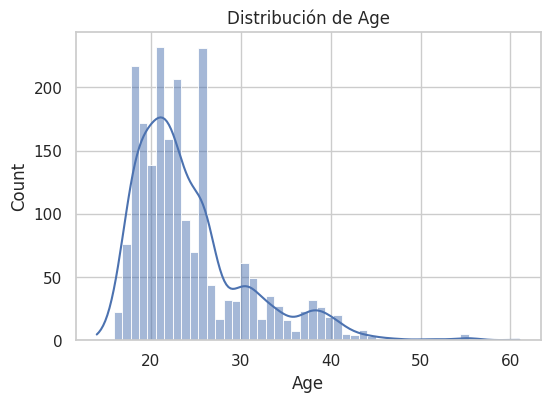

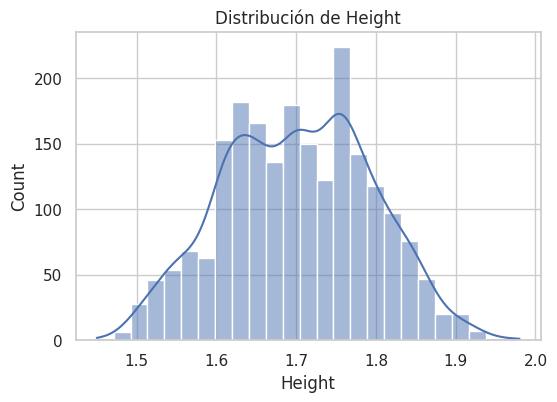

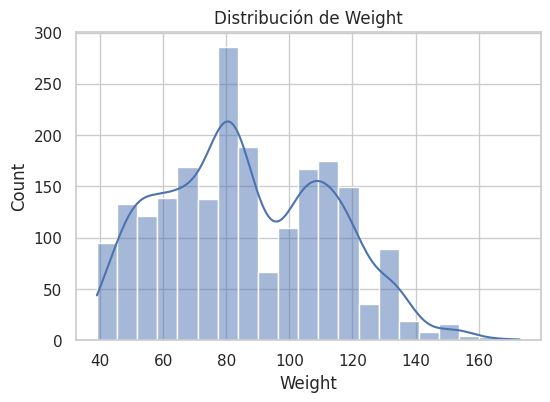

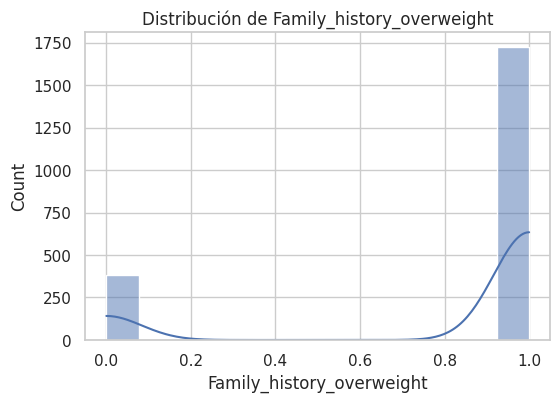

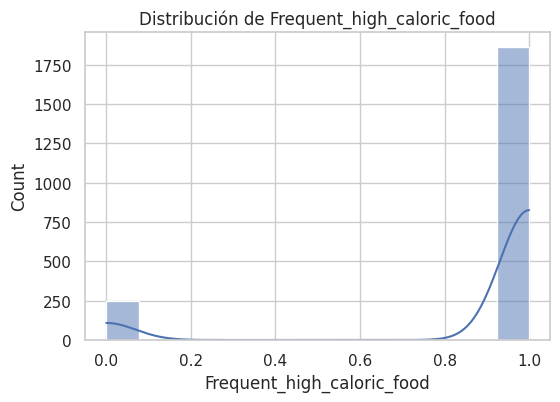

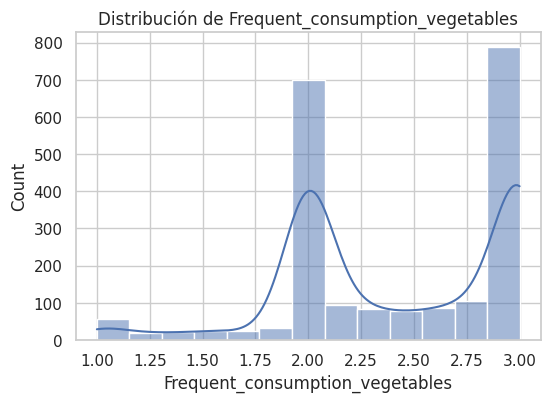

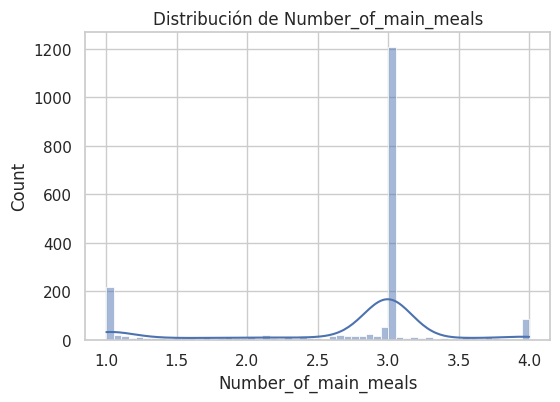

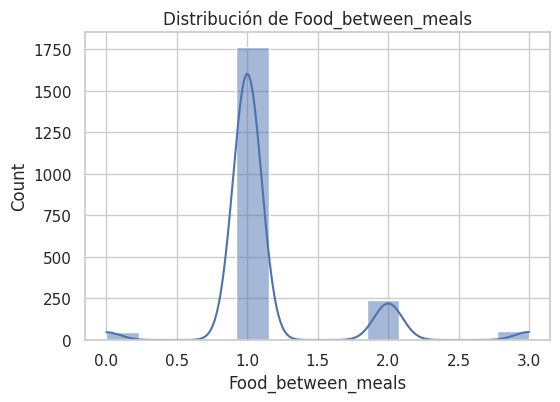

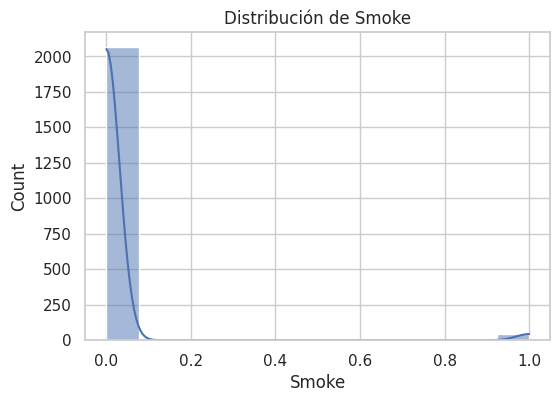

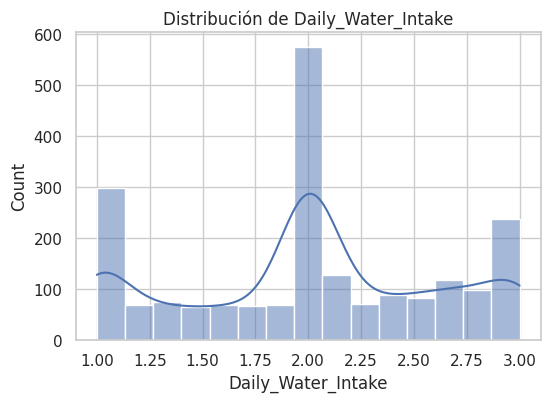

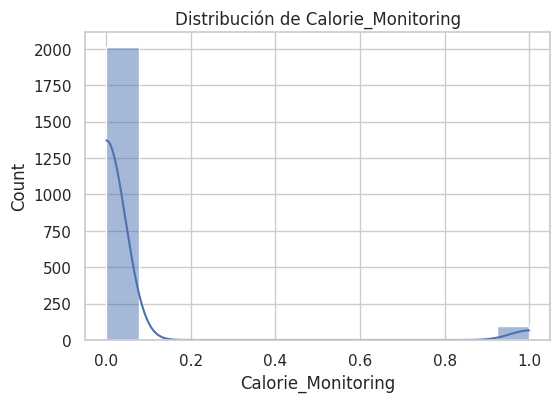

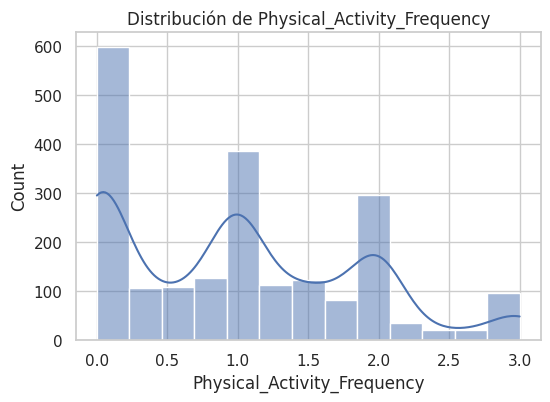

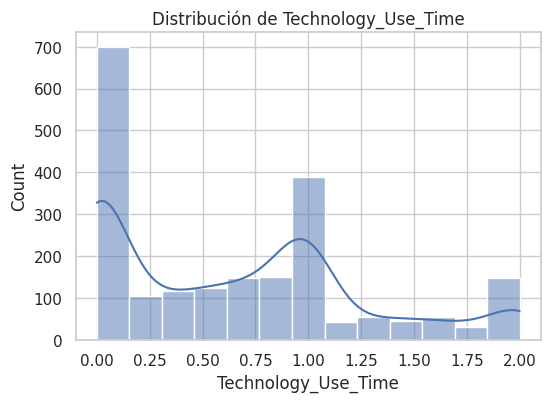

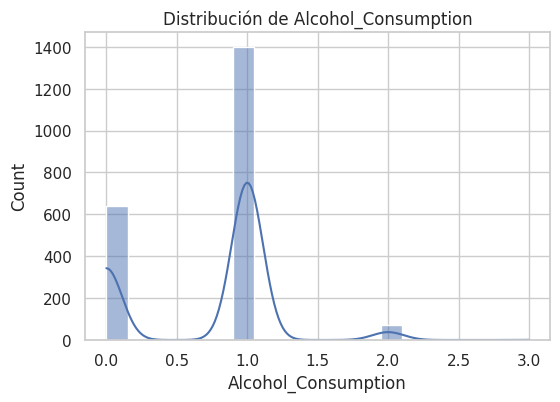

In [13]:
#VISUALIZACIONES
#Histograma y KDE
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(Obesidad_DataSet[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

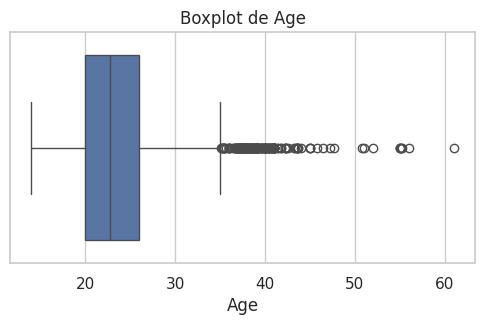

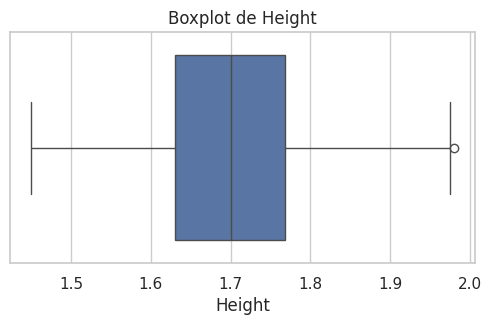

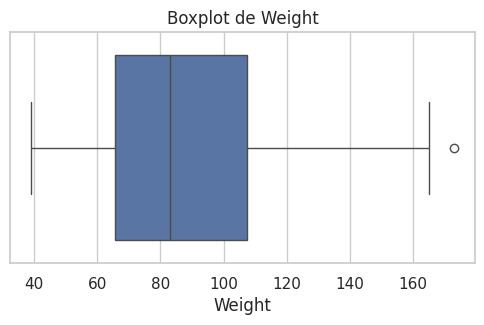

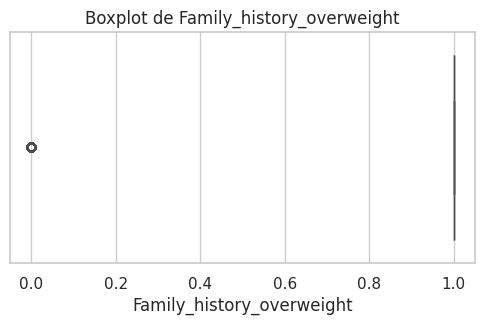

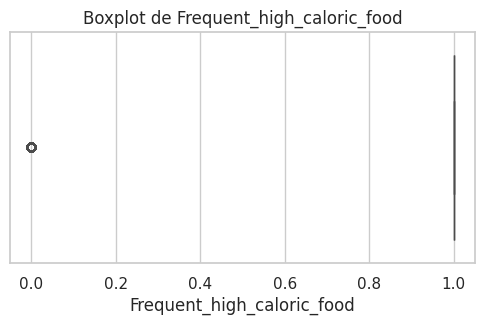

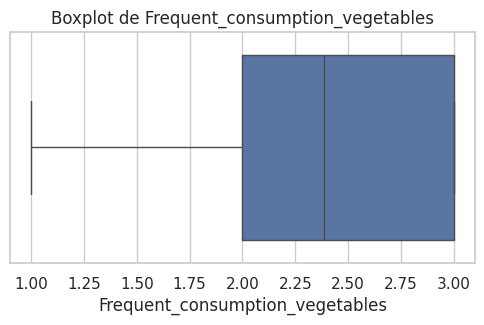

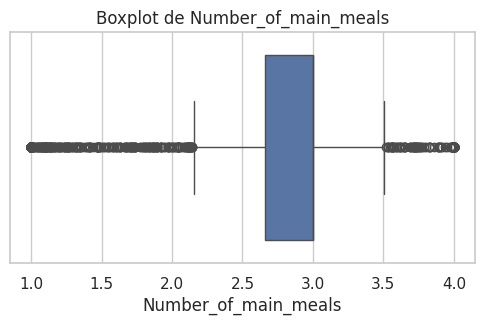

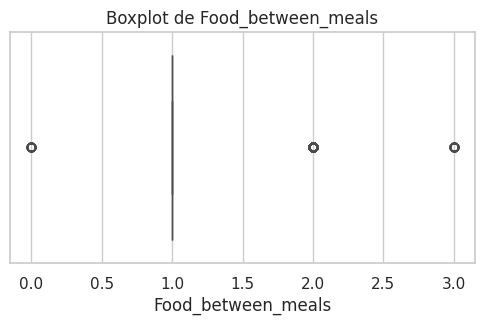

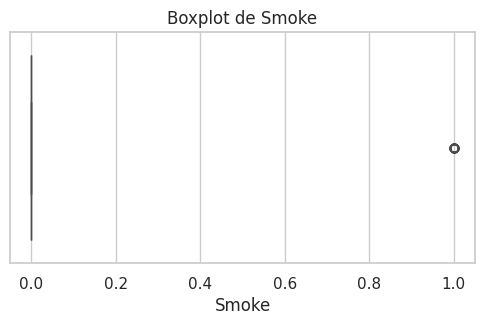

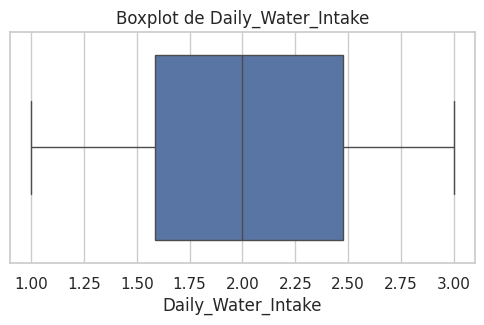

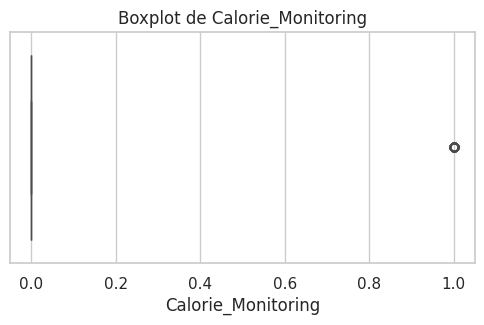

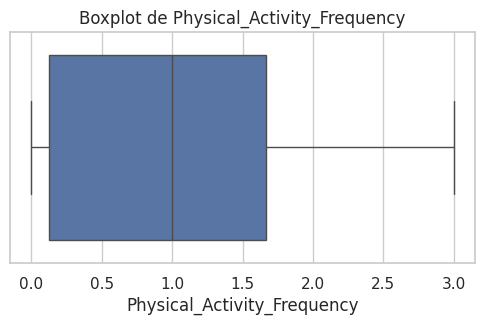

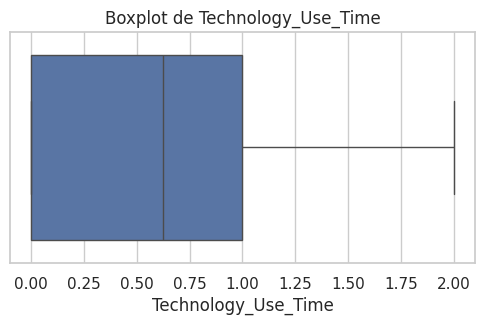

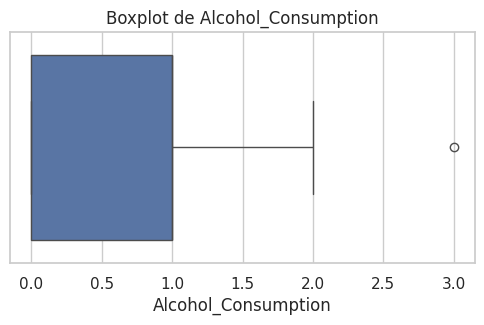

In [14]:
#Boxplots (outliers)
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=Obesidad_DataSet[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

### ***3.1 Analisis variables categóricas***


In [15]:
#Analisis de frecuencias
for col in cat_cols:
    print(f"\n {col}")
    print(Obesidad_DataSet[col].value_counts())


 Gender
Gender
Male      1068
Female    1043
Name: count, dtype: int64

 Transportation_type
Transportation_type
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

 Obesity_Level
Obesity_Level
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [16]:
#Categorias dominantes
for col in cat_cols:
    print(f"\n Categoría dominante en {col}")
    print(Obesidad_DataSet[col].value_counts().idxmax())


 Categoría dominante en Gender
Male

 Categoría dominante en Transportation_type
Public_Transportation

 Categoría dominante en Obesity_Level
Obesity_Type_I


In [17]:
#Categorías atipicas
for col in cat_cols:
    print(f"\n Categorías atipicas en {col}")
    print(Obesidad_DataSet[col].value_counts()[Obesidad_DataSet[col].value_counts() < 50])


 Categorías atipicas en Gender
Series([], Name: count, dtype: int64)

 Categorías atipicas en Transportation_type
Transportation_type
Motorbike    11
Bike          7
Name: count, dtype: int64

 Categorías atipicas en Obesity_Level
Series([], Name: count, dtype: int64)


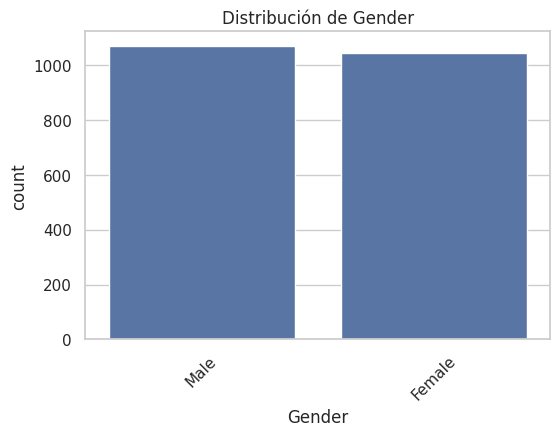

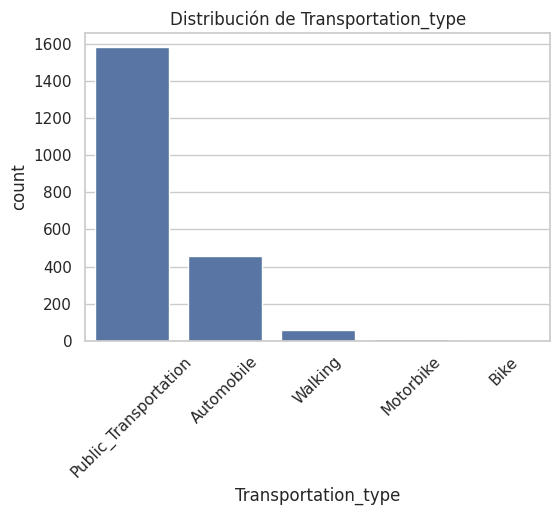

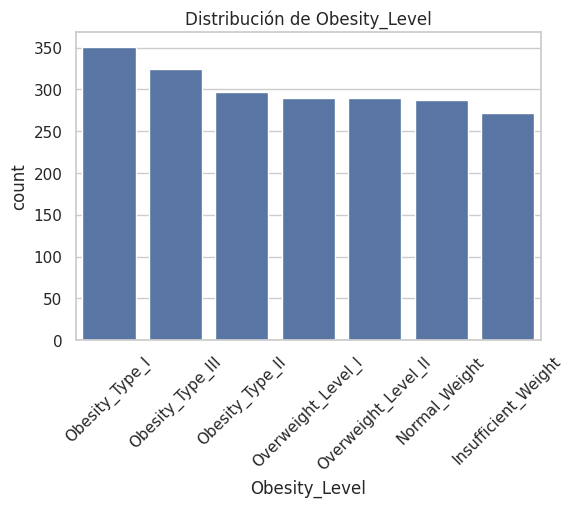

In [18]:
#Grafica de frecuencias
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=Obesidad_DataSet, x=col, order=Obesidad_DataSet[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    plt.show()

## **4. Análisis de relaciones entre variables**

### ***4.1. Numérica vs Númerica***

Edad vs Peso para determinar si la edad es un factor de riesgo para la obesidad

In [19]:
#Prueba de normalidad a las variables para determinar la prueba de crrelación a usar

##Variable Altura

stat, p = stats.shapiro(Obesidad_DataSet["Age"])

print("Age")
print("Estadístico:", stat)
print("p-value:", p)

if p > 0.05:
    print("✅ Distribución NORMAL \n")
else:
    print("❌ Distribución NO normal \n")

## Variable Peso
stat, p = stats.shapiro(Obesidad_DataSet["Weight"])

print("Weight")
print("Estadístico:", stat)
print("p-value:", p)

if p > 0.05:
    print("✅ Distribución NORMAL \n")
else:
    print("❌ Distribución NO normal \n")


Age
Estadístico: 0.8660647214902881
p-value: 3.5182779187666774e-39
❌ Distribución NO normal 

Weight
Estadístico: 0.9765006019820156
p-value: 3.770147371500454e-18
❌ Distribución NO normal 



### ***4.1. Categórica vs Categórica***

Sexo vs Nivel de Obesidad para determinar si hay un género que predomine en los niveles de Obesidad.

In [20]:
tabla_genero_obesidad = pd.crosstab(
    Obesidad_DataSet["Gender"],
    Obesidad_DataSet["Obesity_Level"]
)

tabla_genero_obesidad

Obesity_Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,173,141,156,2,323,145,103
Male,99,146,195,295,1,145,187


In [29]:
tabla_genero_obesidad_norm = pd.crosstab(
    Obesidad_DataSet["Gender"],
    Obesidad_DataSet["Obesity_Level"],
    normalize="index"
)*100

tabla_genero_obesidad_norm.round(2).astype(str)+ "%"

Obesity_Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,16.59%,13.52%,14.96%,0.19%,30.97%,13.9%,9.88%
Male,9.27%,13.67%,18.26%,27.62%,0.09%,13.58%,17.51%


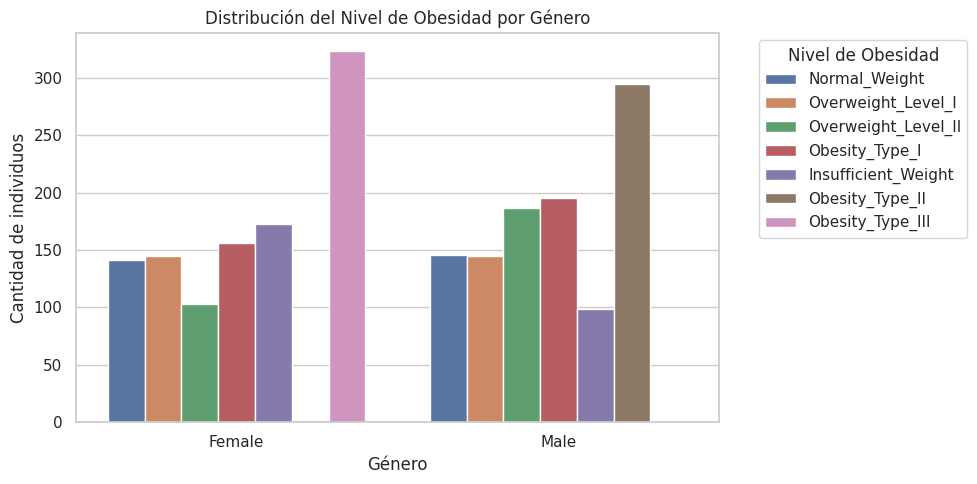

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=Obesidad_DataSet,
    x="Gender",
    hue="Obesity_Level"
)
plt.title("Distribución del Nivel de Obesidad por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad de individuos")
plt.xticks(rotation=0)
plt.legend(
    title="Nivel de Obesidad",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

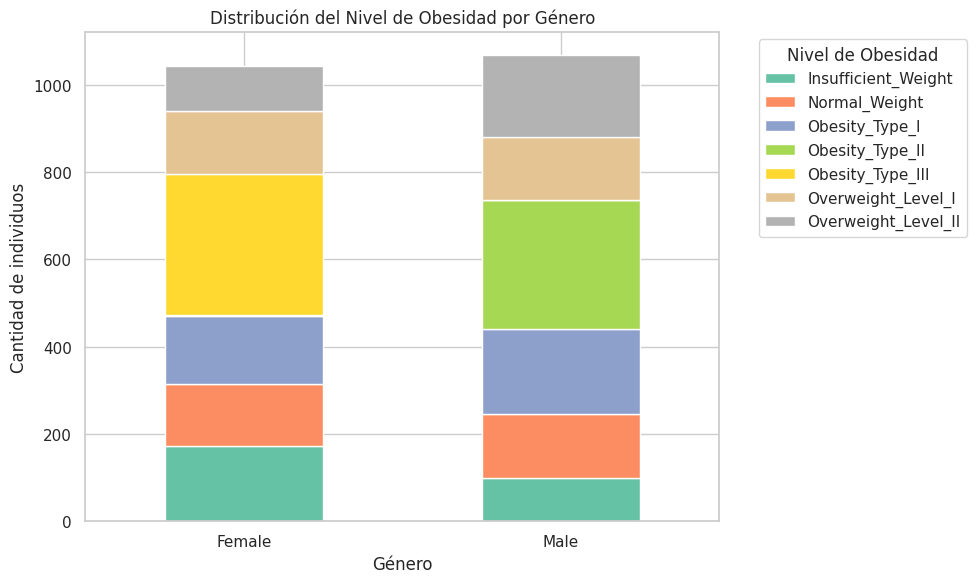

In [21]:
tabla_genero_obesidad.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="Set2"
)

plt.title("Distribución del Nivel de Obesidad por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad de individuos")
plt.xticks(rotation=0)
plt.legend(
    title="Nivel de Obesidad",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [30]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(tabla_genero_obesidad)

print(f"Chi-cuadrado: {chi2:.3f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("✅ Existe una relación estadísticamente significativa entre el género y el nivel de obesidad.")
else:
    print("❌ No se evidencia una relación estadísticamente significativa entre el género y el nivel de obesidad.")


Chi-cuadrado: 657.746
p-value: 0.00000
✅ Existe una relación estadísticamente significativa entre el género y el nivel de obesidad.


**Interpretación:**
El resultado del analisis gráfico, se observan diferencias en la distribución de los niveles de obesidad entre hombres y mujeres evidenciando que algunos niveles se concentran en un genero especifico, por lo cual se evidencia que existe una relación entre el genero y el nivel de obesidad por lo que el genero podría considerarse un factor relevante en el analisis de esta variable

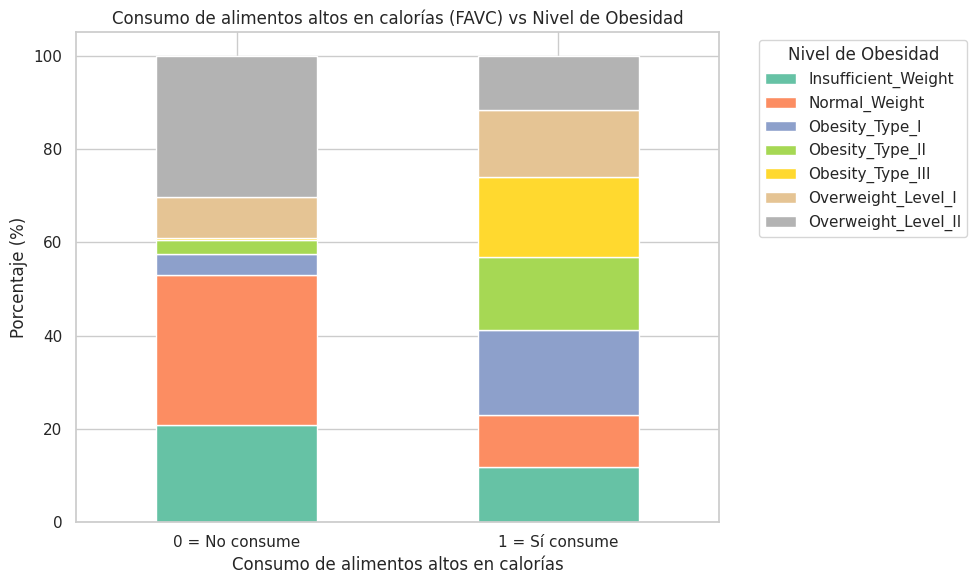

In [37]:
#Consumo de alimentos altos en calorías (FAVC) vs Obesidad


tabla_favc = pd.crosstab(
    Obesidad_DataSet["Frequent_high_caloric_food"],
    Obesidad_DataSet["Obesity_Level"],
    normalize="index"
).mul(100).round(2)

tabla_favc


#Gráfica con etiquetas personalizadas (0 y 1)


ax = tabla_favc.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="Set2"
)

# Etiquetas personalizadas para el eje X
ax.set_xticklabels(
    ["0 = No consume", "1 = Sí consume"],
    rotation=0
)

# Títulos y etiquetas
plt.title("Consumo de alimentos altos en calorías (FAVC) vs Nivel de Obesidad")
plt.xlabel("Consumo de alimentos altos en calorías")
plt.ylabel("Porcentaje (%)")

# Leyenda
plt.legend(
    title="Nivel de Obesidad",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Interpretación:**

Se observa que las personas que consumen frecuentemente alimentos altos en calorías presentan una mayor proporción en los niveles elevados de obesidad. La prueba Chi‑cuadrado confirma que esta relación es estadísticamente significativa, lo que sugiere que el consumo de alimentos altos en calorías está asociado con el nivel de obesidad.


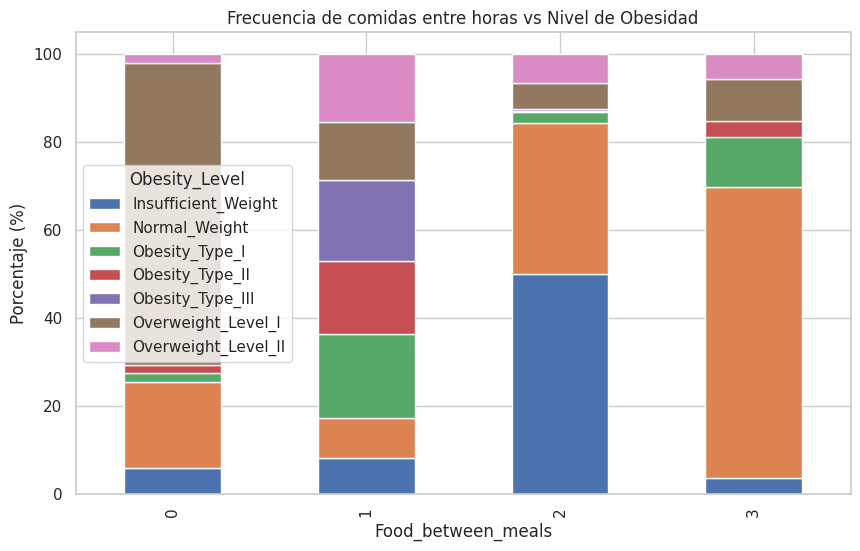

In [33]:
#Comidas entre horas (CAEC) vs Obesidad
#Tabla en %

tabla_caec = pd.crosstab(
    Obesidad_DataSet["Food_between_meals"],
    Obesidad_DataSet["Obesity_Level"],
    normalize="index"
).mul(100).round(2)

tabla_caec

#Gráfica

tabla_caec.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)
plt.ylabel("Porcentaje (%)")
plt.title("Frecuencia de comidas entre horas vs Nivel de Obesidad")
plt.show()

**Interpretación:**

Se identifica una tendencia creciente en los niveles de obesidad a medida que aumenta la frecuencia de consumo de alimentos entre comidas, lo que indica que este hábito podría estar relacionado con un mayor nivel de obesidad.


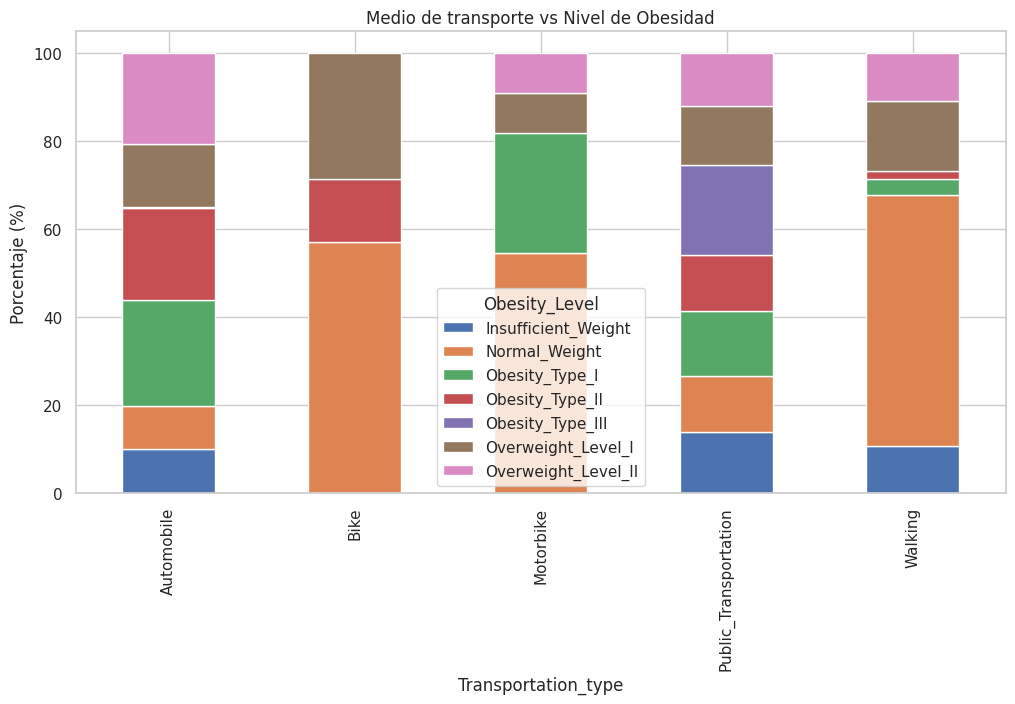

In [38]:
#Medio de transporte (MTRANS) vs Obesidad

tabla_transporte = pd.crosstab(
    Obesidad_DataSet["Transportation_type"],
    Obesidad_DataSet["Obesity_Level"],
    normalize="index"
).mul(100).round(2)

tabla_transporte

#Gráfica

tabla_transporte.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)
plt.ylabel("Porcentaje (%)")
plt.title("Medio de transporte vs Nivel de Obesidad")
plt.show()

**Interpretación:**
Los medios de transporte pasivos presentan mayores proporciones en niveles elevados de obesidad, mientras que los medios activos muestran una mayor presencia en niveles normales o bajos de obesidad.

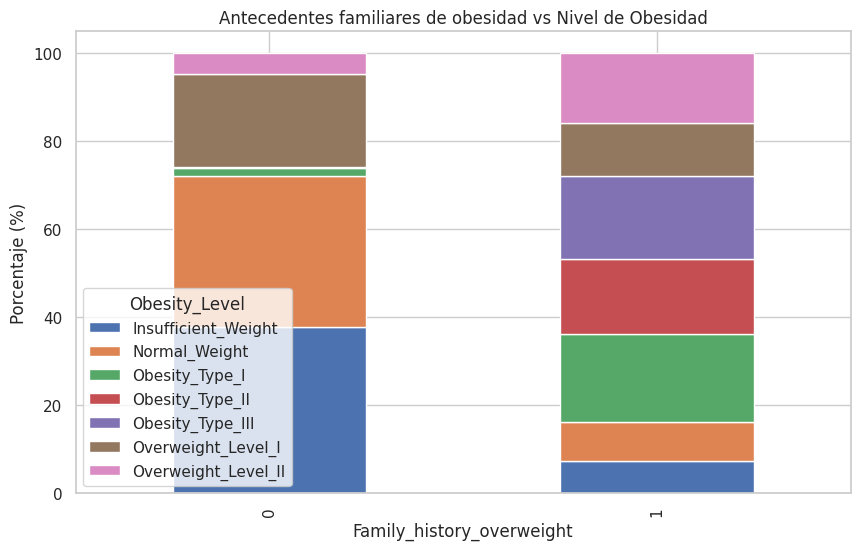

In [39]:
#Antecedentes familiares vs Obesidad
 #Tabla en %

tabla_familiar = pd.crosstab(
    Obesidad_DataSet["Family_history_overweight"],
    Obesidad_DataSet["Obesity_Level"],
    normalize="index"
).mul(100).round(2)

tabla_familiar

#Gráfica

tabla_familiar.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)
plt.ylabel("Porcentaje (%)")
plt.title("Antecedentes familiares de obesidad vs Nivel de Obesidad")
plt.show()

**Interpretación:**
Se evidencia que los individuos con antecedentes familiares de obesidad presentan una mayor proporción en los niveles más altos de obesidad, lo que sugiere una posible influencia genética y/o de hábitos familiares.

### ***4.3. Númerica vs Categórica***


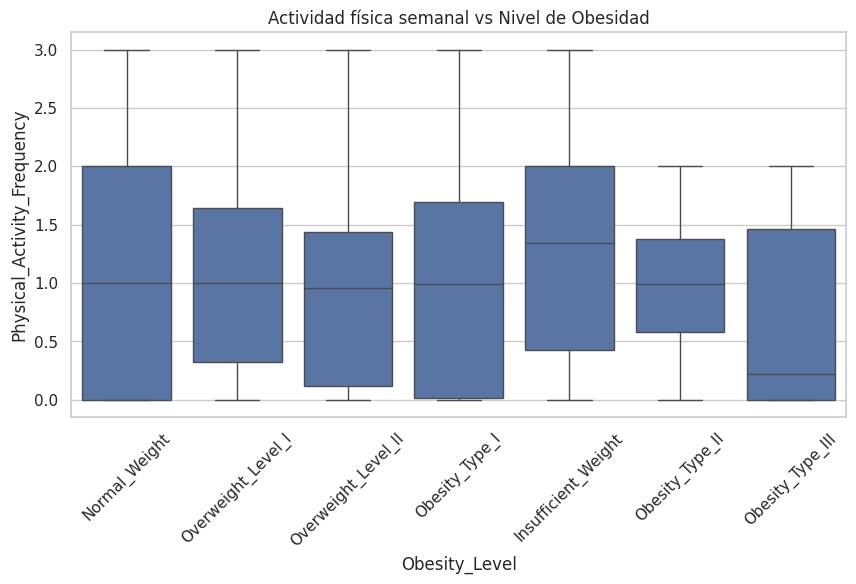

In [34]:
#Actividad física (FAF) vs Obesidad
 #Boxplot

plt.figure(figsize=(10,5))
sns.boxplot(
    data=Obesidad_DataSet,
    x="Obesity_Level",
    y="Physical_Activity_Frequency"
)
plt.xticks(rotation=45)
plt.title("Actividad física semanal vs Nivel de Obesidad")
plt.show()

**Interpretación:**

Los niveles más altos de obesidad presentan, en promedio, una menor frecuencia de actividad física semanal, lo que sugiere una relación inversa entre la actividad física y el nivel de obesidad.

## **5. Creación de Features**

In [43]:
#Índice de hábitos poco saludables (variable compuesta)

Obesidad_DataSet["Unhealthy_Habits_Index"] = (
    Obesidad_DataSet["Frequent_high_caloric_food"] +
    Obesidad_DataSet["Food_between_meals"] +
    (3 - Obesidad_DataSet["Frequent_consumption_vegetables"]) +
    Obesidad_DataSet["Alcohol_Consumption"]
)

#Nivel de sedentarismo

Obesidad_DataSet["Sedentary_Level"] = (
    Obesidad_DataSet["Technology_Use_Time"] -
    Obesidad_DataSet["Physical_Activity_Frequency"]
)

#Clasificación de actividad física (baja / media / alta)

Obesidad_DataSet["Physical_Activity_Level"] = pd.cut(
    Obesidad_DataSet["Physical_Activity_Frequency"],
    bins=[-1, 1, 3, 10],
    labels=["Baja", "Media", "Alta"]
)

#Transporte activo vs pasivo

transporte_activo = ["Walking", "Bike"]

Obesidad_DataSet["Active_Transport"] = Obesidad_DataSet["Transportation_type"].isin(
    transporte_activo
).astype(int)

#Riesgo familiar + hábitos (interacción)

Obesidad_DataSet["Family_Risk_x_Habits"] = (
    Obesidad_DataSet["Family_history_overweight"] *
    Obesidad_DataSet["Unhealthy_Habits_Index"]
)

#Clasificación de consumo de agua (adecuado / bajo)

Obesidad_DataSet["Water_Intake_Level"] = pd.cut(
    Obesidad_DataSet["Daily_Water_Intake"],
    bins=[0, 1.5, 3, 10],
    labels=["Bajo", "Adecuado", "Alto"]
)

#Clasificación edad
Obesidad_DataSet["Age_Group"] = pd.cut(
    Obesidad_DataSet["Age"],
    bins=[0, 18, 30, 45, 100],
    labels=["Adolescente", "Adulto joven", "Adulto", "Adulto mayor"]
)